# Preços de combustíveis: estados, mapa e tempo

Esta expansão compara estados dentro de cada região, detalha a série mensal e verifica se existe variação por dia da semana. Como a fonte só registra estado, produto e semana, o mapa será estadual — não municipal ou por posto.

## A base permite uma comparação espacial por cidade?

Vamos conferir a granularidade disponível antes de associar coordenadas. O uso de coordenadas de capital como se fossem medições municipais produziria uma interpretação incorreta.

In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:,.3f}'.format
raiz = Path.cwd()
while not (raiz / '.data').exists() and raiz != raiz.parent:
    raiz = raiz.parent

In [2]:
arquivo = raiz / 'data' / 'postos_combustivel.tsv'
df = pd.read_csv(arquivo, sep='\t', encoding='utf-8')
df['DATA INICIAL'] = pd.to_datetime(df['DATA INICIAL'])
df['DATA FINAL'] = pd.to_datetime(df['DATA FINAL'])
print('Linhas e colunas:', df.shape)
print('Estados:', df['ESTADO'].nunique(), '| Produtos:', df['PRODUTO'].nunique())
df[['DATA INICIAL', 'DATA FINAL', 'REGIÃO', 'ESTADO', 'PRODUTO']].head(3)

Linhas e colunas: (120823, 18)
Estados: 27 | Produtos: 9


,DATA INICIAL,DATA FINAL,REGIÃO,ESTADO,PRODUTO
0,2004-05-09,2004-05-15,CENTRO OESTE,DISTRITO FEDERAL,ETANOL HIDRATADO
1,2004-05-09,2004-05-15,CENTRO OESTE,GOIAS,ETANOL HIDRATADO
2,2004-05-09,2004-05-15,CENTRO OESTE,MATO GROSSO,ETANOL HIDRATADO


**Resultado:** não há coluna de cidade, município, latitude, longitude ou identificador de posto. A escala espacial defensável é a UF; o IBGE entra como fonte da malha territorial oficial, não como fonte de preços municipais.

## Como padronizar produtos e preparar períodos mensais?

A mesma normalização da análise anterior será reaplicada para tornar comparáveis as grafias com e sem acentos.

In [3]:
import unicodedata
def normaliza_texto(valor):
    texto = unicodedata.normalize('NFKD', str(valor)).encode('ascii', 'ignore').decode('ascii')
    return ' '.join(texto.upper().split())

df['PRODUTO'] = df['PRODUTO'].map(normaliza_texto)
colunas_numericas = ['NÚMERO DE POSTOS PESQUISADOS'] + [c for c in df.columns if 'PREÇO' in c or 'MARGEM' in c or 'COEF' in c or 'DESVIO' in c]
df[colunas_numericas] = df[colunas_numericas].apply(pd.to_numeric, errors='coerce').fillna(0)
df['MES'] = df['DATA INICIAL'].dt.to_period('M').dt.to_timestamp()
df[['PRODUTO', 'DATA INICIAL', 'MES']].head(3)

,PRODUTO,DATA INICIAL,MES
0,ETANOL HIDRATADO,2004-05-09,2004-05-01
1,ETANOL HIDRATADO,2004-05-09,2004-05-01
2,ETANOL HIDRATADO,2004-05-09,2004-05-01


## Quais estados lideram e ficam na parte inferior dentro de cada região?

A comparação será feita por produto, região e estado, exibindo quantidade de registros e postos médios. O ranking usa preço médio simples dos registros, não volume vendido.

In [4]:
estado_produto = (df.groupby(['PRODUTO', 'REGIÃO', 'ESTADO'], as_index=False)
    .agg(preco_medio=('PREÇO MÉDIO REVENDA', 'mean'), registros=('PREÇO MÉDIO REVENDA', 'size'),
         postos_medios=('NÚMERO DE POSTOS PESQUISADOS', 'mean')))
estado_produto['posto_registro'] = estado_produto['postos_medios'] / estado_produto['registros']
estado_produto.sort_values(['PRODUTO', 'REGIÃO', 'preco_medio'], ascending=[True, True, False]).head(15)

,PRODUTO,REGIÃO,ESTADO,preco_medio,registros,postos_medios,posto_registro
0,ETANOL HIDRATADO,CENTRO OESTE,DISTRITO FEDERAL,2.446,873,76.349,0.087
3,ETANOL HIDRATADO,CENTRO OESTE,MATO GROSSO DO SUL,2.335,873,119.094,0.136
1,ETANOL HIDRATADO,CENTRO OESTE,GOIAS,2.126,873,255.459,0.293
2,ETANOL HIDRATADO,CENTRO OESTE,MATO GROSSO,2.076,873,149.907,0.172
7,ETANOL HIDRATADO,NORDESTE,MARANHAO,2.528,873,79.334,0.091
10,ETANOL HIDRATADO,NORDESTE,PIAUI,2.520,873,66.780,0.076
12,ETANOL HIDRATADO,NORDESTE,SERGIPE,2.496,873,45.451,0.052
11,ETANOL HIDRATADO,NORDESTE,RIO GRANDE DO NORTE,2.494,873,95.121,0.109
6,ETANOL HIDRATADO,NORDESTE,CEARA,2.493,873,206.622,0.237
4,ETANOL HIDRATADO,NORDESTE,ALAGOAS,2.485,873,85.019,0.097


In [5]:
produto_foco = 'GASOLINA COMUM'
ranking_foco = estado_produto[estado_produto['PRODUTO'].eq(produto_foco)]
ranking_foco = ranking_foco.sort_values(['REGIÃO', 'preco_medio'], ascending=[True, False])
ranking_foco.groupby('REGIÃO', group_keys=False).head(3)[['REGIÃO', 'ESTADO', 'preco_medio', 'registros']]

,REGIÃO,ESTADO,preco_medio,registros
56,CENTRO OESTE,MATO GROSSO,3.316,873
55,CENTRO OESTE,GOIAS,3.206,873
54,CENTRO OESTE,DISTRITO FEDERAL,3.189,873
58,NORDESTE,ALAGOAS,3.263,873
59,NORDESTE,BAHIA,3.214,873
60,NORDESTE,CEARA,3.212,873
67,NORTE,ACRE,3.574,873
73,NORTE,TOCANTINS,3.324,873
71,NORTE,RONDONIA,3.317,873
76,SUDESTE,RIO DE JANEIRO,3.308,873


**Leitura crítica:** os três maiores estados de cada região são pontos de atenção, não oportunidades automáticas. Diferenças podem refletir logística, composição da amostra, tributos e estrutura concorrencial; a base não permite isolar esses fatores.

## Como o preço mensal varia entre estados de uma mesma região?

A linha mensal mostra se a diferença regional é persistente ou concentrada em períodos específicos. O exemplo usa gasolina comum por ser um produto com ampla cobertura.

In [6]:
mensal_estado = (df[df['PRODUTO'].eq(produto_foco)]
    .groupby(['MES', 'REGIÃO', 'ESTADO'], as_index=False)['PREÇO MÉDIO REVENDA'].mean())
print('Meses:', mensal_estado['MES'].nunique(), '| Estados:', mensal_estado['ESTADO'].nunique())
mensal_estado.tail(8)

Meses: 203 | Estados: 27


,MES,REGIÃO,ESTADO,PREÇO MÉDIO REVENDA
5473,2021-04-01,NORTE,TOCANTINS,5.741
5474,2021-04-01,SUDESTE,ESPIRITO SANTO,5.562
5475,2021-04-01,SUDESTE,MINAS GERAIS,5.761
5476,2021-04-01,SUDESTE,RIO DE JANEIRO,6.048
5477,2021-04-01,SUDESTE,SAO PAULO,5.225
5478,2021-04-01,SUL,PARANA,5.218
5479,2021-04-01,SUL,RIO GRANDE DO SUL,5.619
5480,2021-04-01,SUL,SANTA CATARINA,5.072


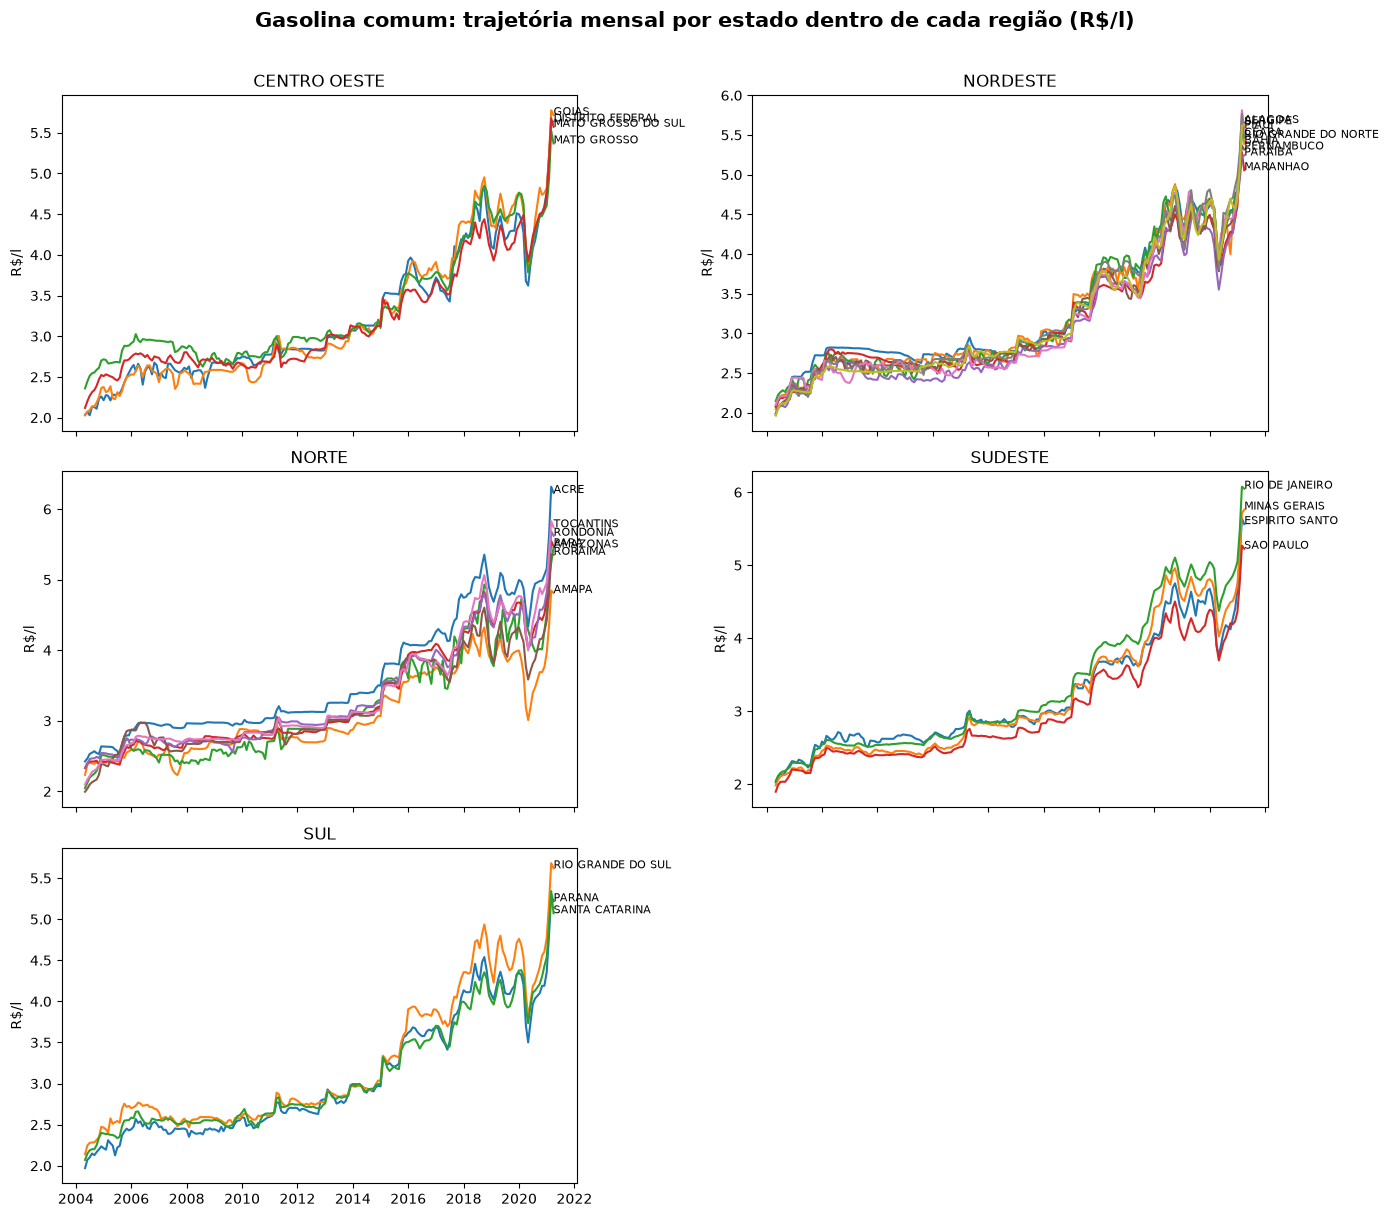

In [7]:
cores_regiao = {'NORTE':'#0072B2', 'NORDESTE':'#E69F00', 'SUDESTE':'#009E73', 'SUL':'#CC79A7', 'CENTRO OESTE':'#D55E00'}
fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)
for ax, regiao in zip(axes.flat, sorted(mensal_estado['REGIÃO'].unique())):
    recorte = mensal_estado[mensal_estado['REGIÃO'].eq(regiao)]
    for estado, serie in recorte.groupby('ESTADO'):
        ax.plot(serie['MES'], serie['PREÇO MÉDIO REVENDA'], label=estado)
        ultimo = serie.iloc[-1]
        ax.annotate(estado, (ultimo['MES'], ultimo['PREÇO MÉDIO REVENDA']), fontsize=8)
    ax.set_title(regiao); ax.set_ylabel('R$/l')
axes.flat[-1].axis('off')
fig.suptitle('Gasolina comum: trajetória mensal por estado dentro de cada região (R$/l)', y=1.01, fontsize=15, fontweight='bold')
plt.tight_layout()

**Leitura crítica:** a granularidade mensal é obtida agregando semanas; ela é adequada para tendência e persistência, mas pode esconder picos dentro do mês. As etiquetas finais identificam os estados sem depender de legenda.

## Existe variação útil por dia da semana?

Vamos verificar quais dias aparecem em `DATA INICIAL` e `DATA FINAL`. Se todos os registros começarem no mesmo dia, não há base para comparar preços por dia da semana.

In [8]:
dias_inicio = df['DATA INICIAL'].dt.day_name('pt_BR').value_counts().to_frame('registros')
dias_fim = df['DATA FINAL'].dt.day_name('pt_BR').value_counts().to_frame('registros')
print('Dias em DATA INICIAL:'); display(dias_inicio)
print('Dias em DATA FINAL:'); display(dias_fim)

Dias em DATA INICIAL:


,registros
DATA INICIAL,
Domingo,120823


Dias em DATA FINAL:


,registros
DATA FINAL,
Sábado,120823


**Resultado:** os dias da semana descrevem o calendário da pesquisa, não necessariamente o dia em que cada preço foi observado no posto. Se houver apenas um dia de início e um de fim, a comparação por dia da semana não é identificável nesta fonte. Para isso, seria necessário dado diário ou data individual da coleta.

## Como ficará o mapa interativo por combustível e mês?

Usaremos a malha estadual oficial do IBGE. O mapa terá filtros de produto e mês; cada UF exibirá preço médio, número de registros e unidade. A geometria é estadual, portanto não representa preços de uma cidade específica.

In [9]:
geojson = json.loads((raiz / 'data' / 'ibge_ufs.geojson').read_text())
print('Geometrias IBGE:', len(geojson['features']))
print('Atributos da geometria:', geojson['features'][0]['properties'])
assert len(geojson['features']) == 27

Geometrias IBGE: 27
Atributos da geometria: {'codarea': '12'}


In [10]:
uf_codigo = {'AC':'12','AL':'27','AP':'16','AM':'13','BA':'29','CE':'23','DF':'53','ES':'32','GO':'52','MA':'21','MT':'51','MS':'50','MG':'31','PA':'15','PB':'25','PR':'41','PE':'26','PI':'22','RJ':'33','RN':'24','RS':'43','RO':'11','RR':'14','SC':'42','SP':'35','SE':'28','TO':'17'}
nome_uf = {'AC':'ACRE','AL':'ALAGOAS','AP':'AMAPA','AM':'AMAZONAS','BA':'BAHIA','CE':'CEARA','DF':'DISTRITO FEDERAL','ES':'ESPIRITO SANTO','GO':'GOIAS','MA':'MARANHAO','MT':'MATO GROSSO','MS':'MATO GROSSO DO SUL','MG':'MINAS GERAIS','PA':'PARA','PB':'PARAIBA','PR':'PARANA','PE':'PERNAMBUCO','PI':'PIAUI','RJ':'RIO DE JANEIRO','RN':'RIO GRANDE DO NORTE','RS':'RIO GRANDE DO SUL','RO':'RONDONIA','RR':'RORAIMA','SC':'SANTA CATARINA','SP':'SAO PAULO','SE':'SERGIPE','TO':'TOCANTINS'}
nome_para_uf = {v:k for k,v in nome_uf.items()}
df['UF'] = df['ESTADO'].map(nome_para_uf)
print('Estados sem correspondência:', int(df['UF'].isna().sum()))
df[['ESTADO', 'UF']].drop_duplicates().head(10)

Estados sem correspondência: 0


,ESTADO,UF
0,DISTRITO FEDERAL,DF
1,GOIAS,GO
2,MATO GROSSO,MT
3,MATO GROSSO DO SUL,MS
4,ALAGOAS,AL
5,BAHIA,BA
6,CEARA,CE
7,MARANHAO,MA
8,PARAIBA,PB
9,PERNAMBUCO,PE


## O artefato permite explorar os preços no mapa?

Será criado um HTML local com Leaflet, filtros de produto e mês e tooltips por UF. Os tiles do mapa são do OpenStreetMap e exigem internet para o fundo cartográfico.

In [11]:
mapa_df = (df.groupby(['MES', 'PRODUTO', 'UF', 'UNIDADE DE MEDIDA'], as_index=False)
    .agg(preco_medio=('PREÇO MÉDIO REVENDA', 'mean'), registros=('PREÇO MÉDIO REVENDA', 'size')))
mapa_df = mapa_df.dropna(subset=['UF'])
dados_mapa = mapa_df.to_dict('records')
meses = sorted(mapa_df['MES'].dt.strftime('%Y-%m').unique())
produtos = sorted(mapa_df['PRODUTO'].unique())
print('Registros no mapa:', len(mapa_df), '| Produtos:', len(produtos), '| Meses:', len(meses))

Registros no mapa: 28337 | Produtos: 7 | Meses: 203


In [12]:
geo_text = json.dumps(geojson, ensure_ascii=False)
dados_text = json.dumps([{**r, 'MES': r['MES'].strftime('%Y-%m')} for r in dados_mapa], ensure_ascii=False)
opcoes_produto = ''.join(f'<option>{p}</option>' for p in produtos)
opcoes_mes = ''.join(f'<option>{m}</option>' for m in meses)
html = f'''<!doctype html><html lang="pt-BR"><head><meta charset="utf-8"><title>Preços de combustíveis por UF</title>
<link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css"><style>body{{font-family:Arial;margin:0;color:#334155}} header{{padding:14px 20px}} #map{{height:78vh}} select{{padding:7px;margin-right:10px}} .info{{background:#fff;padding:8px;box-shadow:0 0 10px #999}} </style></head><body><header><h2>Preços médios de revenda por UF</h2><label>Produto <select id="produto">{opcoes_produto}</select></label><label>Mês <select id="mes">{opcoes_mes}</select></label><p>Fonte de preço: ANP na base fornecida. Malha: IBGE. Escala estadual; não representa preço municipal.</p></header><div id="map"></div><script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script><script>const geo={geo_text}; const dados={dados_text}; const ufCodigo={json.dumps(uf_codigo)}; const mapa=L.map('map').setView([-14.2,-51.9],4); L.tileLayer('https://{{s}}.tile.openstreetmap.org/{{z}}/{{x}}/{{y}}.png',{{attribution:'&copy; OpenStreetMap contributors'}}).addTo(mapa); let camada; function cor(v,min,max){{if(v==null)return '#e5e7eb'; const t=(v-min)/((max-min)||1); const r=Math.round(255-140*t), g=Math.round(245-115*t), b=Math.round(235-25*t); return `rgb(${{r}},${{g}},${{b}})`;}} function atualiza(){{const p=document.getElementById('produto').value,m=document.getElementById('mes').value; const rec=dados.filter(d=>d.PRODUTO===p&&d.MES===m); const porUf=Object.fromEntries(rec.map(d=>[d.UF,d])); const vals=rec.map(d=>d.preco_medio), min=Math.min(...vals), max=Math.max(...vals); if(camada)mapa.removeLayer(camada); camada=L.geoJSON(geo,{{style:f=>{{const d=porUf[Object.keys(ufCodigo).find(u=>ufCodigo[u]===f.properties.codarea)]; return {{fillColor:cor(d?.preco_medio,min,max),weight:1,color:'#fff',fillOpacity:.8}};}},onEachFeature:(f,l)=>{{const u=Object.keys(ufCodigo).find(x=>ufCodigo[x]===f.properties.codarea),d=porUf[u]; l.bindTooltip(`<b>${{u}}</b><br>${{d?`${{d.preco_medio.toFixed(3)}} ${{d.UNIDADE_DE_MEDIDA}}<br>${{d.registros}} registros`:'Sem dado'}}`);}}}}).addTo(mapa);}} document.getElementById('produto').onchange=atualiza; document.getElementById('mes').onchange=atualiza; atualiza();</script></body></html>'''
saida = raiz / 'outputs' / 'mapa-precos-combustiveis.html'
saida.parent.mkdir(exist_ok=True)
saida.write_text(html, encoding='utf-8')
print('Mapa salvo em:', saida)

Mapa salvo em: /Users/danillosantanadearaujo/Documents/Python Scripts/Data Science/outputs/mapa-precos-combustiveis.html


## Síntese e próximos passos

- **Escala espacial:** a análise e o mapa são válidos por UF; não há cidade ou posto individual na fonte.
- **Comparação regional:** o ranking estadual permite localizar diferenças persistentes e estados para investigação, sempre com `n` de registros.
- **Tempo:** a série mensal é possível e foi implementada; o dia da semana não é comparável se a base só registra semanas agregadas.
- **Mapa:** o arquivo interativo permite selecionar combustível e mês. Os tiles do OpenStreetMap requerem internet; os dados e a malha estão incorporados no HTML.
- **Evolução recomendada:** incluir município/posto e data diária da ANP, ou outra fonte diária geocodificada, para chegar ao nível de cidade e analisar feriados e dias da semana com validade.